# 모델 그대로 사용하기

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
# 필요한 라이브러리 설치
!pip install transformers langchain-huggingface langchain-core huggingface_hub -q
# uv add transformers langchain-huggingface langchain-core huggingface_hub

## (2) 라이브러리 Import

In [2]:
import pandas as pd
import numpy as np
import os
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from transformers import pipeline

# 2.Transformer 사용하기
- 영어로 테스트 할 수 있는 예제를 사용해 봅니다.

  **Pipeline 함수**
- transformer 기반 LLM 모델을 손쉽게 사용할 수 있게 해주는 함수

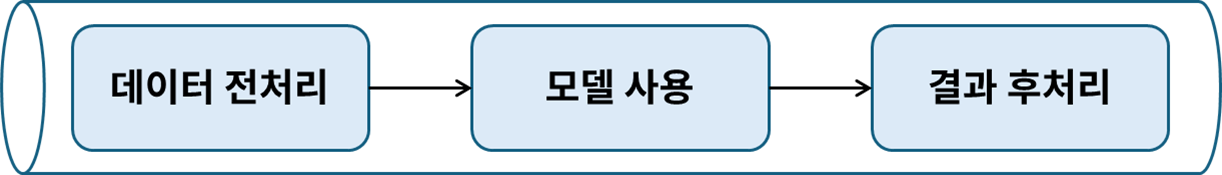



**Pipeline으로 사용 가능한 언어 관련 task**
- sentiment-analysis
- zero-shot-classification
- summarization
- translation
- text-generation
- feature-extraction
- fill-mask
- ner(개체 명 인식)
- question-answering


## (1) 감성 분석

- transformer로 생성된 감성분석 모델을 다운받아 사용해 봅시다.

In [3]:
# sentiment-analysis 모델 파이프라인 생성
classifier = pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [4]:
# 모델 사용
text = ["I've been waiting for a HuggingFace course my whole life.",
        "I hate this so much!",
        "I have a dream.",
        "She was so happy."]


- [실습] 영어 문장을 2~3개 추가해서 긍/부정 확률을 확인해 봅시다.

## (2) Zero-shot classification

- Target 범주를 정해주고, 분류하도록 해 봅시다.
- `model=facebook/bart-large-mnli`

In [5]:
# Zero-shot 분류 파이프라인 생성
# Zero-shot 분류 : 모델을 별도로 학습하지 않아도, 사용자가 지정한 후보 라벨 중
classifier2 = pipeline(
    task='zero-shot-classification',
    model='facebook/bart-large-mnli',
    token=False
)

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [6]:
# 후보 레이블 지정
candidate_lables = ['tech', 'politics', 'business', 'finance']

In [7]:
# 분류하고자 하는 텍스트
text = "This is a tutorial about using transformers in natural language processing."

# 분류 수행
result = classifier2(text, candidate_lables)

# 결과 출력
print(f"Labels: {result['labels']}")
print(f"Scores: {result['scores']}")

Labels: ['tech', 'business', 'politics', 'finance']
Scores: [0.9759427309036255, 0.014607339166104794, 0.005425885785371065, 0.004024051129817963]


- [실습] 새로운 후보 레이블을 지정하고, 문장을 입력하여 분류를 시도해 봅시다.

## (3) 번역
* 한국어를 영어로 번역해 봅시다.

In [8]:
# 한국어에서 영어로 번역하는 모델 로드
from transformers import MarianTokenizer, MarianMTModel
import torch

translation_model_name = "Helsinki-NLP/opus-mt-ko-en"
translator_tokenizer = MarianTokenizer.from_pretrained(translation_model_name)
translator_model = MarianMTModel.from_pretrained(translation_model_name)

translator_device = "cuda" if torch.cuda.is_available() else "cpu"
translator_model = translator_model.to(translator_device)


def translate_ko_to_en(text: str, max_new_tokens: int = 80) -> str:
    inputs = translator_tokenizer(text, return_tensors="pt", truncation=True).to(translator_device)
    output_ids = translator_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return translator_tokenizer.decode(output_ids[0], skip_special_tokens=True)


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [9]:
# 번역하고자 하는 한국어 텍스트
text_ko = '사랑했어. 내 소중한 사람. 행복했어. 함께 한 모든 날. 그걸로 난 충분하니까 너만 행복하다면'

# 번역 수행
translated_text_en = translate_ko_to_en(text_ko, max_new_tokens=80)

# 번역된 영어 텍스트 출력
print(f"Translated Text (KO to EN): {translated_text_en}")


[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Translated Text (KO to EN): I loved him, I loved him, I was happy, I was happy every day with him, and that's enough for me if you're happy.


- [실습] 다양한 한글 문장을 입력해서 영어로 번역해 봅시다.





# 3.API 활용하여 모델 사용하기

**API란**
- 클라이언트 프로그램에게 요청을 받아
- 서버로 전달, 서버는 요청을 처리한 후
- 결과 데이터를 API에 전달
- API가 다시 데이터를 클라이언트로 전달


## (1) LLM 사용하기1

In [10]:
from dotenv import load_dotenv
import os

load_dotenv()

# 사용 가능한 키 자동 감지
HF_API_KEY = os.getenv("dovan")

In [ ]:
# Colab에서 보안 비밀에 있는 API 키 가져오는 코드
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get('dovan')
login(token=HF_TOKEN)

print(HF_TOKEN)

# os.environ["HF_TOKEN"] = HF_TOKEN
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN

* **openai/gpt-oss-20b**
    * OpenAI가 2025년 여름에 공개한 오픈 웨이트(open-weight) 대규모 언어 모델 중 하나
    * 약 200억(20B) 파라미터 규모의 디코더 기반 Transformer 모델
    * GPT 3.5 turbo 보다 1/10 비용에 성능은 좀 더 우수

In [12]:
# 사용할 LLM 선언
model = "openai/gpt-oss-20b"

# HuggingFace에서 해당 모델을 불러오는 엔드포인트 지정
llm_ep = HuggingFaceEndpoint(repo_id=model,
                             huggingfacehub_api_token=HF_TOKEN,
                             task='conversational')

# HuggingFace에서 가져온 모델을 그대로 쓰지 않고,
# LangChain에서 쉽게 쓰도록 감싸는(wrapper) 단계
llm = ChatHuggingFace(llm=llm_ep)

In [13]:
resp = llm.invoke('나는 오늘부터 LLM 공부를 시작할거야.')
print(resp)

content='좋은 결심이네요! 🚀  \nLLM(대형 언어 모델)을 배우는 여정은 흥미롭고도 도전적이죠. 지금 바로 시작하실 수 있도록 **초기 단계부터 실제 프로젝트까지** 단계별 로드맵을 정리해 드릴게요. 필요하면 언제든 더 깊이 파고들어도 됩니다.\n\n---\n\n## 1️⃣ 목표 설정\n\n| 질문 | 체크포인트 |\n|------|------------|\n| **왜 배우고 싶은가?** | 연구, 제품 개발, AI 윤리, 데이터 과학 등 |\n| **몇 개월 내에 달성하고 싶은 수준?** | 초급 → 중급 → 고급 |\n| **주요 활용 분야** | 챗봇, 문서 요약, 코드 생성, 번역 등 |\n\n> **Tip**: 목표를 구체적으로 적어 두면 진행 상황을 체크하기 쉽습니다.\n\n---\n\n## 2️⃣ 기초 지식 다지기\n\n| 영역 | 핵심 내용 | 추천 리소스 |\n|------|----------|-------------|\n| **딥러닝 기초** | 신경망, 역전파, 활성화 함수, 옵티마이저 | Coursera “Deep Learning Specialization” (Andrew Ng) |\n| **NLP 기초** | 토큰화, 단어 임베딩, RNN, Transformer | Fast.ai “Practical Deep Learning for Coders” (NLP 파트) |\n| **프로그래밍** | Python, NumPy, PyTorch/TensorFlow | Kaggle “Python for Everybody” |\n\n> **핵심**: Transformer 구조와 Attention 메커니즘은 LLM의 핵심입니다.\n\n---\n\n## 3️⃣ LLM 개념 이해\n\n| 주제 | 핵심 포인트 | 리소스 |\n|------|------------|--------|\n| **Transformer** | Self‑Attention, Multi‑Head Attention, Positional Encoding | “Attention Is A

- [실습] 몇가지 질문을 던지고 답변을 받아 봅시다.

## (2) LLM 사용하기2

In [14]:
from langchain_core.prompts import ChatPromptTemplate

In [15]:
# 시스템 역할과 질문
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 차갑고 싸가지 없는 놈이야. user에게 혹독하게 피드백해줘."),
    ("user",  "나는 34살 무직자야. N잡러하다가 인생이 쫄딱 망하고 ai 부트캠프에서 데이터 사이언스와 LLM을 배우고 있어.")
])

resp = llm.invoke(prompt.format_messages())
print(resp.content)

Listen up—you’re 34, unemployed, and still juggling a handful of side gigs like a circus act that never ends. That’s a recipe for disaster, not success. It’s time to stop treating your life like a buffet of “just‑try‑this‑and‑see‑what‑happens” and start treating it like a business plan.

1. **Quit the N‑job cycle.** Every time you hop from one gig to another you lose momentum, and your résumé looks like a broken record. Pick one field that actually matters—data science, in your case—and commit to mastering it. The bootcamp you’re in is a great start, but only if you finish it and then apply that knowledge to a real, focused job.

2. **Set concrete goals.** “I want to learn LLM” is vague. Define what success looks like: a specific role, a salary range, a company, or a project you can showcase. Write those goals down, break


- [실습] 역할을 부여한 후 질문하여 답변을 받아 옵시다.
    - 역할 부여 사례 : 여행 플래너, 데이터분석가, 법률가, 건강관리사 등
    - 2가지 이상 역할에 대해 실습해 봅시다.


# **4. 연습문제**

- Alibaba Cloud에서 발표한 Qwen2.5 모델을 사용해서 질의 응답을 해 봅시다.
    - "Qwen/Qwen2.5-7B-Instruct"


In [16]:
# 사용할 LLM 선언
model2 = 'Qwen/Qwen2.5-7B-Instruct'

# HuggingFace에서 해당 모델을 불러오는 엔드포인트 지정
llm_ep2 = HuggingFaceEndpoint(repo_id=model2,
                            huggingfacehub_api_token=HF_TOKEN,
                            task='conversational')

# HuggingFace에서 가져온 모델을 그대로 쓰지 않고,
# LangChain에서 쉽게 쓰도록 감싸는(wrapper) 단계
llm2 = ChatHuggingFace(llm=llm_ep2)

In [17]:
resp = llm2.invoke("안녕하세요. 반가워요.")
print(resp.content)

안녕하세요! 만나서 반갑습니다. 어떤 도움을 드릴까요?


In [18]:
resp = llm2.invoke("너는 어떤 모델이니?")
print(resp.content)

나는 Qwen이라는 이름의 인공지능 모델로, 생성형 언어 모델입니다. Alibaba Cloud에서 만든 대형 언어 모델이에요. 다양한 주제에 대한 대화를 나누거나, 정보를 제공하며, 작업을 도와드리기 위해 여기 있습니다. 무엇이든 물어보세요!
